In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 5080
12.8
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
tensor([2., 4., 6.], device='cuda:0')


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
vi_features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method', 'rdvi_noir_rgb_method', 'savi_noir_rgb_method', 'sr_noir_rgb_method','evi_noir_rgb_method', 'cigreen_noir_rgb_method' ]

features = vi_features + ['lepton_mean_temp', 'lepton_min_temp', 'lepton_max_temp']
output_variable = 'GYLD_kg_m3'

Text(0.5, 1.0, 'Train vs Test Yield Distribution')

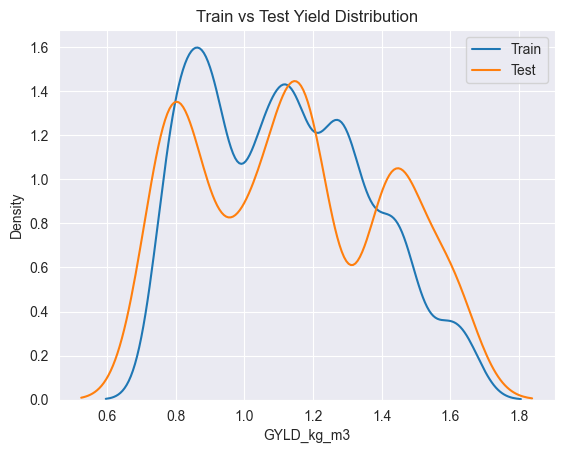

In [5]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets_v2.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets_v2.xlsx", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [7]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1084
test_df_scaled Rows with at least one NaN: 354


In [ ]:
# print(X_test_scaled.shape)

In [10]:
window_size = 30
pad_value = -99

K-fold cross validation

In [ ]:
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
plot_ids = train_df['plot_id'].unique()
yield_per_plot = train_df.groupby('plot_id')[output_variable].first().values

y_bins = pd.qcut(yield_per_plot, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
from helper import make_progressive_windows
from model_definitions import GRUModel
from vi_dataset import VIDataset

def k_fold_cross_validation(batch_size, k_fold_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(plot_ids, y_bins)):
        print(f"Fold {fold+1}")

        train_plots = plot_ids[train_idx]
        val_plots   = plot_ids[val_idx]

        train_df_fold = train_df[train_df['plot_id'].isin(train_plots)]
        val_df_fold   = train_df[train_df['plot_id'].isin(val_plots)]

        # Scaling
        scaler_X_fold = StandardScaler()
        scaler_y_fold = RobustScaler()

        scaler_X_fold.fit(train_df_fold[features])
        scaler_y_fold.fit(train_df_fold[[output_variable]])

        train_df_fold_scaled = train_df_fold.copy()
        val_df_fold_scaled  = val_df_fold.copy()

        train_df_fold_scaled[features] = scaler_X_fold.transform(train_df_fold[features])
        train_df_fold_scaled[output_variable] = scaler_y_fold.transform(train_df_fold[[output_variable]])

        val_df_fold_scaled[features] = scaler_X_fold.transform(val_df_fold[features])
        val_df_fold_scaled[output_variable] = scaler_y_fold.transform(val_df_fold[[output_variable]])

        X_train_fold, y_train_fold = make_progressive_windows(
            dataframe=train_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        X_val_fold, y_val_fold = make_progressive_windows(
            dataframe=val_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        train_dataset_fold = VIDataset(X_train_fold, y_train_fold)
        val_dataset_fold = VIDataset(X_val_fold, y_val_fold)

        train_loader_fold  = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
        val_loader_fold    = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)

        model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                         output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

        train_data(
            model = model,
            model_train_loader= train_loader_fold,
            num_epochs = k_fold_epochs,
            learning_rate = learning_rate,
            weight_decay = weight_decay,
            hyper_param_criterion_method = hyper_param_criterion_method,
            file_save_name=""
        )

        r2, mse = evaluate_model(
            model = model,
            val_loader = val_loader_fold,
            output_variable_scaler=scaler_y_fold)

        r2_scores.append(r2)
        print(f"Fold {fold+1} R²: {r2:.4f}")

    mean_r2 = np.mean(r2_scores)
    print(f"\n✅ Mean R² across folds: {mean_r2:.4f}")
    return mean_r2

In [15]:
import optuna
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

search_space = {
    "hidden_size": [8, 16, 32 , 64],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "lr":  [0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [8, 16, 32, 64],
}

tuning_epochs = 500

def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = k_fold_cross_validation(
        batch_size= batch_size,
        k_fold_epochs=tuning_epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# sampler = optuna.samplers.GridSampler(search_space)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


In [16]:


cols_to_pad = ['lepton_max_temp', 'lepton_min_temp', 'lepton_mean_temp']
train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [17]:
from helper import make_progressive_windows
from vi_dataset import VIDataset

X_train_scaled, y_train_scaled = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)


train_dataset = VIDataset(X_train_scaled, y_train_scaled)
test_dataset = VIDataset(X_test_scaled, y_test_scaled)


In [18]:
from model_definitions import GRUModel

def validation_with_test(trial_id, batch_size, num_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    train_loader_tuning  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader_tuning    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader_tuning,
        num_epochs = num_epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse = evaluate_model(
        model = model,
        val_loader = test_loader_tuning,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [20]:
epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        num_epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [21]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=100)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-11-06 11:51:37,678] A new study created in memory with name: no-name-d1893caa-381d-4515-9602-92e094b32488
C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2326998747907157 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/1000] - Train Loss: 0.13088
Epoch [2/1000] - Train Loss: 0.10750
Epoch [3/1000] - Train Loss: 0.09321
Epoch [4/1000] - Train Loss: 0.08280
Epoch [5/1000] - Train Loss: 0.07650
Epoch [6/1000] - Train Loss: 0.07137
Epoch [7/1000] - Train Loss: 0.06796
Epoch [8/1000] - Train Loss: 0.06521
Epoch [9/1000] - Train Loss: 0.06347
Epoch [10/1000] - Train Loss: 0.06160
Epoch [11/1000] - Train Loss: 0.06067
Epoch [12/1000] - Train Loss: 0.05878
Epoch [13/1000] - Train Loss: 0.05769
Epoch [14/1000] - Train Loss: 0.05665
Epoch [15/1000] - Train Loss: 0.05701
Epoch [16/1000] - Train Loss: 0.05559
Epoch [17/1000] - Train Loss: 0.05572
Epoch [18/1000] - Train Loss: 0.05637
Epoch [19/1000] - Train Loss: 0.05425
Epoch [20/1000] - Train Loss: 0.05436
Epoch [21/1000] - Train Loss: 0.05427
Epoch [22/1000] - Train Loss: 0.05268
Epoch [23/1000] - Train Loss: 0.05235
Epoch [24/1000] - Train Loss: 0.05419
Epoch [25/1000] - Train Loss: 0.05264
Epoch [26/1000] - Train Loss: 0.05266
Epoch [27/1000] - Tra

[I 2025-11-06 11:52:33,995] Trial 0 finished with value: 0.423221230506897 and parameters: {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2326998747907157, 'lr': 0.0018093997541825805, 'weight_decay': 4.421596587465827e-05, 'batch_size': 8}. Best is trial 0 with value: 0.423221230506897.


Epoch [171/1000] - Train Loss: 0.04364
Early stopping triggered.
 R²: 0.4232
Epoch [1/1000] - Train Loss: 0.15472
Epoch [2/1000] - Train Loss: 0.12460
Epoch [3/1000] - Train Loss: 0.11372
Epoch [4/1000] - Train Loss: 0.11031
Epoch [5/1000] - Train Loss: 0.10671
Epoch [6/1000] - Train Loss: 0.10050
Epoch [7/1000] - Train Loss: 0.09759
Epoch [8/1000] - Train Loss: 0.09060
Epoch [9/1000] - Train Loss: 0.09031
Epoch [10/1000] - Train Loss: 0.08715
Epoch [11/1000] - Train Loss: 0.08480
Epoch [12/1000] - Train Loss: 0.08178
Epoch [13/1000] - Train Loss: 0.08089
Epoch [14/1000] - Train Loss: 0.07972
Epoch [15/1000] - Train Loss: 0.08008
Epoch [16/1000] - Train Loss: 0.07789
Epoch [17/1000] - Train Loss: 0.07857
Epoch [18/1000] - Train Loss: 0.07791
Epoch [19/1000] - Train Loss: 0.07730
Epoch [20/1000] - Train Loss: 0.07347
Epoch [21/1000] - Train Loss: 0.07534
Epoch [22/1000] - Train Loss: 0.07427
Epoch [23/1000] - Train Loss: 0.07580
Epoch [24/1000] - Train Loss: 0.07453
Epoch [25/1000] - Tr

[I 2025-11-06 11:53:14,492] Trial 1 finished with value: 0.22629791498184204 and parameters: {'hidden_size': 16, 'num_layers': 3, 'dropout': 0.10779948684692109, 'lr': 0.0006735112607796868, 'weight_decay': 0.0007702572718216016, 'batch_size': 16}. Best is trial 0 with value: 0.423221230506897.


...

Epoch [1/1000] - Train Loss: 0.14781
Epoch [2/1000] - Train Loss: 0.12473
Epoch [3/1000] - Train Loss: 0.11904
Epoch [4/1000] - Train Loss: 0.11572
Epoch [5/1000] - Train Loss: 0.11356
Epoch [6/1000] - Train Loss: 0.11206
Epoch [7/1000] - Train Loss: 0.11009
Epoch [8/1000] - Train Loss: 0.10893
Epoch [9/1000] - Train Loss: 0.10715
Epoch [10/1000] - Train Loss: 0.10529
Epoch [11/1000] - Train Loss: 0.10389
Epoch [12/1000] - Train Loss: 0.10047
Epoch [13/1000] - Train Loss: 0.09782
Epoch [14/1000] - Train Loss: 0.09618
Epoch [15/1000] - Train Loss: 0.09364
Epoch [16/1000] - Train Loss: 0.09243
Epoch [17/1000] - Train Loss: 0.09079
Epoch [18/1000] - Train Loss: 0.08887
Epoch [19/1000] - Train Loss: 0.08846
Epoch [20/1000] - Train Loss: 0.08739
Epoch [21/1000] - Train Loss: 0.08600
Epoch [22/1000] - Train Loss: 0.08555
Epoch [23/1000] - Train Loss: 0.08394
Epoch [24/1000] - Train Loss: 0.08353
Epoch [25/1000] - Train Loss: 0.08337
Epoch [26/1000] - Train Loss: 0.08174
Epoch [27/1000] - Tra

[I 2025-11-06 12:47:00,874] Trial 98 finished with value: 0.31978845596313477 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.07960465580925893, 'lr': 0.00012019349088371881, 'weight_decay': 0.0008084111161999362, 'batch_size': 8}. Best is trial 87 with value: 0.44834256172180176.


Epoch [89/1000] - Train Loss: 0.07208
Early stopping triggered.
 R²: 0.3198
Epoch [1/1000] - Train Loss: 0.13671
Epoch [2/1000] - Train Loss: 0.11563
Epoch [3/1000] - Train Loss: 0.10420
Epoch [4/1000] - Train Loss: 0.09495
Epoch [5/1000] - Train Loss: 0.08920
Epoch [6/1000] - Train Loss: 0.08641
Epoch [7/1000] - Train Loss: 0.08054
Epoch [8/1000] - Train Loss: 0.07727
Epoch [9/1000] - Train Loss: 0.07521
Epoch [10/1000] - Train Loss: 0.07404
Epoch [11/1000] - Train Loss: 0.07070
Epoch [12/1000] - Train Loss: 0.06864
Epoch [13/1000] - Train Loss: 0.06586
Epoch [14/1000] - Train Loss: 0.06394
Epoch [15/1000] - Train Loss: 0.06362
Epoch [16/1000] - Train Loss: 0.06241
Epoch [17/1000] - Train Loss: 0.06241
Epoch [18/1000] - Train Loss: 0.06142
Epoch [19/1000] - Train Loss: 0.06122
Epoch [20/1000] - Train Loss: 0.05871
Epoch [21/1000] - Train Loss: 0.05806
Epoch [22/1000] - Train Loss: 0.05657
Epoch [23/1000] - Train Loss: 0.05477
Epoch [24/1000] - Train Loss: 0.05537
Epoch [25/1000] - Tra

[I 2025-11-06 12:47:54,512] Trial 99 finished with value: 0.1699085831642151 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.20730174166974272, 'lr': 0.00030953466298448706, 'weight_decay': 1.1115959467428059e-10, 'batch_size': 8}. Best is trial 87 with value: 0.44834256172180176.


Epoch [174/1000] - Train Loss: 0.01596
Early stopping triggered.
 R²: 0.1699
Best R²: 0.4483
Best hyperparameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.10344360354230203, 'lr': 0.0002476906474606584, 'weight_decay': 0.0005347879641161282, 'batch_size': 8}


In [30]:
# =============================================
#  Train the best model with best hyper params
# =============================================

# Best R²: 0.4483
# criterion_method = L1 Loss
best_gru_params =  {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.10344360354230203, 'lr': 0.0002476906474606584, 'weight_decay': 0.0005347879641161282, 'batch_size': 8}


best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.10344360354230203 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/500] - Train Loss: 0.13915
Epoch [2/500] - Train Loss: 0.11706
Epoch [3/500] - Train Loss: 0.11202
Epoch [4/500] - Train Loss: 0.10440
Epoch [5/500] - Train Loss: 0.09868
Epoch [6/500] - Train Loss: 0.09555
Epoch [7/500] - Train Loss: 0.09218
Epoch [8/500] - Train Loss: 0.08868
Epoch [9/500] - Train Loss: 0.08711
Epoch [10/500] - Train Loss: 0.08388
Epoch [11/500] - Train Loss: 0.08194
Epoch [12/500] - Train Loss: 0.08024
Epoch [13/500] - Train Loss: 0.07819
Epoch [14/500] - Train Loss: 0.07704
Epoch [15/500] - Train Loss: 0.07596
Epoch [16/500] - Train Loss: 0.07462
Epoch [17/500] - Train Loss: 0.07388
Epoch [18/500] - Train Loss: 0.07246
Epoch [19/500] - Train Loss: 0.07136
Epoch [20/500] - Train Loss: 0.07106
Epoch [21/500] - Train Loss: 0.07000
Epoch [22/500] - Train Loss: 0.06987
Epoch [23/500] - Train Loss: 0.06814
Epoch [24/500] - Train Loss: 0.06761
Epoch [25/500] - Train Loss: 0.06792
Epoch [26/500] - Train Loss: 0.06659
Epoch [27/500] - Train Loss: 0.06608
Epoch [28/

ValueError: x and y must have same first dimension, but have shapes (74,) and (128,)

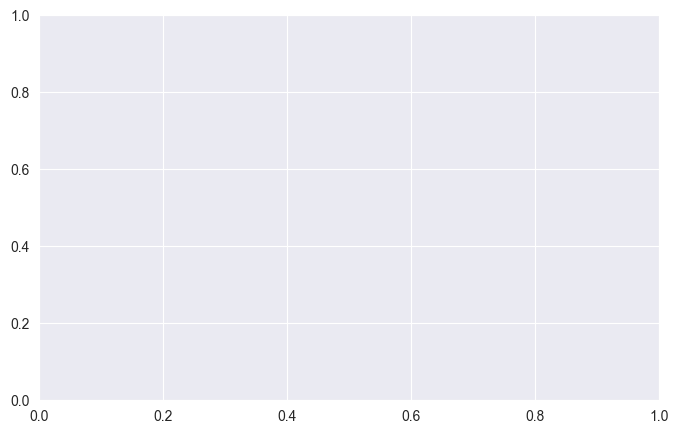

In [31]:
from train_eval_functions import train_data

# Optional: Train again with best hyper parameters

train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

epochs = 500
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru1.pth",
            early_stopping = True,
        )


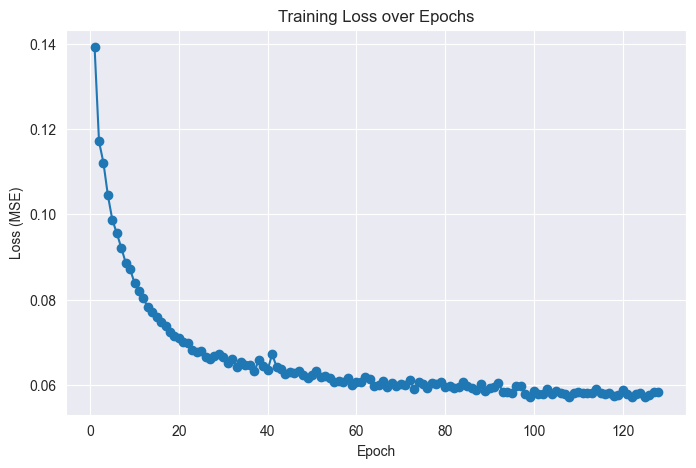

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 128+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

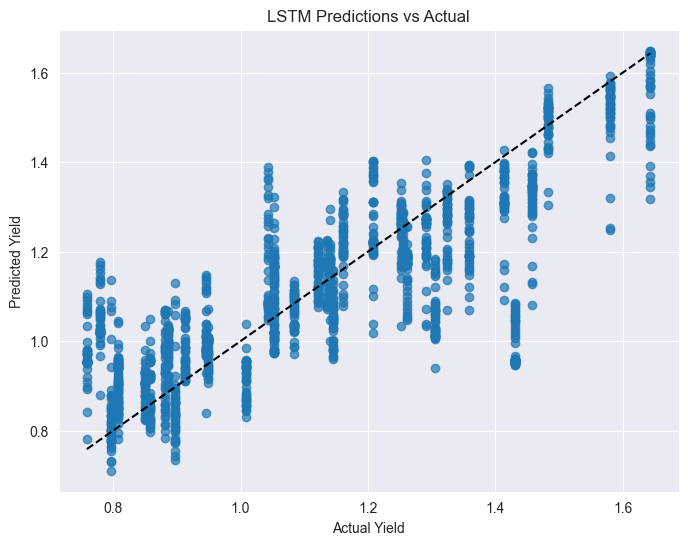

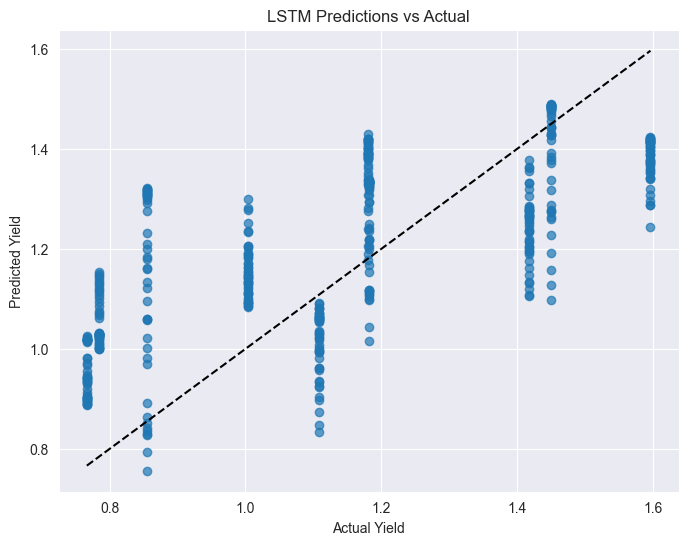

Train R²: 0.6743, Train MSE: 0.0187
Test R²: 0.4415, Test MSE: 0.0420


In [34]:
from train_eval_functions import evaluate_model

best_model.load_state_dict(torch.load("best_gru_models/best_model_hyper_param_1.pth", map_location=device))

# Training metrics
r2_train, mse_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [35]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_1.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_1.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_1.save")

['best_gru_models/scalers/scaler_y_1.save']